In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Artifacts will be saved to: {ARTIFACTS_DIR.resolve()}")

Device: cuda
Artifacts will be saved to: /data/source/personal/awesome-ai-engineer/homeworks/HW13/artifacts


In [2]:
raw_datasets = load_dataset("dair-ai/emotion")
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
for split, ds in raw_datasets.items():
    print(f"{split:12s}: {len(ds):6d} examples")

train       :  16000 examples
validation  :   2000 examples
test        :   2000 examples


In [4]:
label_feature = raw_datasets["train"].features["label"]
label_names   = label_feature.names # ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
num_labels    = len(label_names)
id2label      = {i: lbl for i, lbl in enumerate(label_names)}
label2id      = {lbl: i  for i, lbl in enumerate(label_names)}

print("Classes:", label_names)

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [5]:
sample_df = pd.DataFrame(raw_datasets["train"].select(range(5)))
sample_df["label_name"] = sample_df["label"].map(id2label)
display(sample_df[["text", "label_name"]])

,text,label_name
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [6]:
train_labels = pd.Series(raw_datasets["train"]["label"]).map(id2label)
print("Class distribution (train):")
print(train_labels.value_counts())

Class distribution (train):
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [7]:
FINETUNE_MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)
print("Tokenizer:", tokenizer.__class__.__name__)

Tokenizer: BertTokenizer


In [8]:
# Special tokens
special_df = pd.DataFrame([
    {"name": "cls_token",    "value": tokenizer.cls_token,    "id": tokenizer.cls_token_id},
    {"name": "sep_token",    "value": tokenizer.sep_token,    "id": tokenizer.sep_token_id},
    {"name": "pad_token",    "value": tokenizer.pad_token,    "id": tokenizer.pad_token_id},
    {"name": "unk_token",    "value": tokenizer.unk_token,    "id": tokenizer.unk_token_id},
    {"name": "mask_token",   "value": tokenizer.mask_token,   "id": tokenizer.mask_token_id},
])
display(special_df)

,name,value,id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


In [9]:
def inspect_tokenization(text: str) -> pd.DataFrame:
    enc      = tokenizer(text, return_attention_mask=True)
    ids      = enc["input_ids"]
    mask     = enc["attention_mask"]
    all_toks = [tokenizer.decode([i]) for i in ids]
    return pd.DataFrame({"token": all_toks, "input_id": ids, "attention_mask": mask})


demo_texts_tok = [
    "I feel so happy today!",
    "This made me really angry and frustrated.",
    "I am a little scared of what might happen.",
    "Wow, I didn't expect that at all!",
    "superkalafragalisticexpialidocious",
]

for txt in demo_texts_tok:
    print(f"\nText: '{txt}'")
    display(inspect_tokenization(txt))


Text: 'I feel so happy today!'


,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,feel,2514,1
3,so,2061,1
4,happy,3407,1
5,today,2651,1
6,!,999,1
7,[SEP],102,1



Text: 'This made me really angry and frustrated.'


,token,input_id,attention_mask
0,[CLS],101,1
1,this,2023,1
2,made,2081,1
3,me,2033,1
4,really,2428,1
5,angry,4854,1
6,and,1998,1
7,frustrated,10206,1
8,.,1012,1
9,[SEP],102,1



Text: 'I am a little scared of what might happen.'


,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,am,2572,1
3,a,1037,1
4,little,2210,1
5,scared,6015,1
6,of,1997,1
7,what,2054,1
8,might,2453,1
9,happen,4148,1



Text: 'Wow, I didn't expect that at all!'


,token,input_id,attention_mask
0,[CLS],101,1
1,wow,10166,1
2,",",1010,1
3,i,1045,1
4,didn,2134,1
5,',1005,1
6,t,1056,1
7,expect,5987,1
8,that,2008,1
9,at,2012,1



Text: 'superkalafragalisticexpialidocious'


,token,input_id,attention_mask
0,[CLS],101,1
1,super,3565,1
2,##kala,26907,1
3,##fra,27843,1
4,##gal,9692,1
5,##istic,6553,1
6,##ex,10288,1
7,##pia,19312,1
8,##lid,21273,1
9,##oc,10085,1


In [10]:
# Padding и truncation на батче
batch_enc = tokenizer(
    demo_texts_tok[:3],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)
print("input_ids shape:", batch_enc["input_ids"].shape)
print("attention_mask shape:", batch_enc["attention_mask"].shape)
print("\ninput_ids:")
print(batch_enc["input_ids"])
print("\nattention_mask (1=реальный токен, 0=pad):")
print(batch_enc["attention_mask"])

input_ids shape: torch.Size([3, 12])
attention_mask shape: torch.Size([3, 12])

input_ids:
tensor([[  101,  1045,  2514,  2061,  3407,  2651,   999,   102,     0,     0,
             0,     0],
        [  101,  2023,  2081,  2033,  2428,  4854,  1998, 10206,  1012,   102,
             0,     0],
        [  101,  1045,  2572,  1037,  2210,  6015,  1997,  2054,  2453,  4148,
          1012,   102]])

attention_mask (1=реальный токен, 0=pad):
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [11]:
PRETRAINED_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_pipeline = pipeline(
    task="text-classification",
    model=PRETRAINED_MODEL,
    device=0 if device.type == "cuda" else -1,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [12]:
inference_texts = [
    "I feel so happy and excited about this!",           # joy
    "I am deeply sad and heartbroken.",                  # sadness
    "This is absolutely terrifying, I can't stop shaking.",  # fear
    "I love you so much, you mean everything to me.",   # love
    "That made me so angry, I can't believe it.",       # anger
    "Oh wow, I had no idea that would happen!",          # surprise
]

results = sentiment_pipeline(inference_texts)

inference_df = pd.DataFrame({
    "text": inference_texts,
    "expected_emotion": ["joy","sadness","fear","love","anger","surprise"],
    "pretrained_label": [r["label"]  for r in results],
    "pretrained_score": [round(r["score"], 3) for r in results],
})
display(inference_df)

,text,expected_emotion,pretrained_label,pretrained_score
0,I feel so happy and excited about this!,joy,POSITIVE,1.000
1,I am deeply sad and heartbroken.,sadness,NEGATIVE,0.996
2,"This is absolutely terrifying, I can't stop sh...",fear,POSITIVE,0.952
3,"I love you so much, you mean everything to me.",love,POSITIVE,1.000
4,"That made me so angry, I can't believe it.",anger,NEGATIVE,0.999
5,"Oh wow, I had no idea that would happen!",surprise,POSITIVE,0.958


In [13]:
MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = raw_datasets.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

print(tokenized_datasets)
print("Example:", {
    k: (v[:5] if v.ndim > 0 else v)
    for k, v in tokenized_datasets["train"][0].items()
})

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})
Example: {'labels': tensor(0), 'input_ids': tensor([ 101, 1045, 2134, 2102, 2514]), 'token_type_ids': tensor([0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1])}


In [14]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Params: 66,958,086


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc      = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {"accuracy": round(acc, 4), "f1_macro": round(f1_macro, 4)}

In [17]:
OUTPUT_DIR = "outputs/hw13_distilbert_emotion"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to="none",
    disable_tqdm=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

try:
    trainer = Trainer(**trainer_kwargs, processing_class=tokenizer)
except TypeError:
    trainer = Trainer(**trainer_kwargs, tokenizer=tokenizer)

train_result = trainer.train()
print("\nTrain completed! Hurray! Yuri wont fuck me up!")
print(train_result.metrics)

{'loss': '1.765', 'grad_norm': '1.595', 'learning_rate': '6.533e-06', 'epoch': '0.1'}
{'loss': '1.527', 'grad_norm': '3.489', 'learning_rate': '1.32e-05', 'epoch': '0.2'}
{'loss': '1.171', 'grad_norm': '3.529', 'learning_rate': '1.987e-05', 'epoch': '0.3'}
{'loss': '0.8675', 'grad_norm': '6.485', 'learning_rate': '1.927e-05', 'epoch': '0.4'}
{'loss': '0.5808', 'grad_norm': '6.561', 'learning_rate': '1.853e-05', 'epoch': '0.5'}
{'loss': '0.4281', 'grad_norm': '5.28', 'learning_rate': '1.779e-05', 'epoch': '0.6'}
{'loss': '0.3638', 'grad_norm': '6.429', 'learning_rate': '1.705e-05', 'epoch': '0.7'}
{'loss': '0.3183', 'grad_norm': '2.361', 'learning_rate': '1.631e-05', 'epoch': '0.8'}
{'loss': '0.2706', 'grad_norm': '5.798', 'learning_rate': '1.557e-05', 'epoch': '0.9'}
{'loss': '0.2644', 'grad_norm': '6.555', 'learning_rate': '1.483e-05', 'epoch': '1'}
{'eval_loss': '0.211', 'eval_accuracy': '0.919', 'eval_f1_macro': '0.8898', 'eval_runtime': '2.717', 'eval_samples_per_second': '736', 'e

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1752', 'grad_norm': '0.9829', 'learning_rate': '1.409e-05', 'epoch': '1.1'}
{'loss': '0.1944', 'grad_norm': '10.85', 'learning_rate': '1.335e-05', 'epoch': '1.2'}
{'loss': '0.1776', 'grad_norm': '7.296', 'learning_rate': '1.261e-05', 'epoch': '1.3'}
{'loss': '0.1619', 'grad_norm': '5.159', 'learning_rate': '1.187e-05', 'epoch': '1.4'}
{'loss': '0.1817', 'grad_norm': '3.235', 'learning_rate': '1.113e-05', 'epoch': '1.5'}
{'loss': '0.1402', 'grad_norm': '4.96', 'learning_rate': '1.039e-05', 'epoch': '1.6'}
{'loss': '0.1877', 'grad_norm': '5.181', 'learning_rate': '9.644e-06', 'epoch': '1.7'}
{'loss': '0.1825', 'grad_norm': '5.72', 'learning_rate': '8.904e-06', 'epoch': '1.8'}
{'loss': '0.185', 'grad_norm': '12.67', 'learning_rate': '8.163e-06', 'epoch': '1.9'}
{'loss': '0.1364', 'grad_norm': '8.714', 'learning_rate': '7.422e-06', 'epoch': '2'}
{'eval_loss': '0.1478', 'eval_accuracy': '0.94', 'eval_f1_macro': '0.9159', 'eval_runtime': '3.521', 'eval_samples_per_second': '568',

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1282', 'grad_norm': '6.163', 'learning_rate': '6.681e-06', 'epoch': '2.1'}
{'loss': '0.1225', 'grad_norm': '16.47', 'learning_rate': '5.941e-06', 'epoch': '2.2'}
{'loss': '0.1192', 'grad_norm': '4.053', 'learning_rate': '5.2e-06', 'epoch': '2.3'}
{'loss': '0.119', 'grad_norm': '5.917', 'learning_rate': '4.459e-06', 'epoch': '2.4'}
{'loss': '0.1167', 'grad_norm': '5.843', 'learning_rate': '3.719e-06', 'epoch': '2.5'}
{'loss': '0.1045', 'grad_norm': '4.142', 'learning_rate': '2.978e-06', 'epoch': '2.6'}
{'loss': '0.1113', 'grad_norm': '8.987', 'learning_rate': '2.237e-06', 'epoch': '2.7'}
{'loss': '0.1086', 'grad_norm': '7.177', 'learning_rate': '1.496e-06', 'epoch': '2.8'}
{'loss': '0.1271', 'grad_norm': '4.75', 'learning_rate': '7.556e-07', 'epoch': '2.9'}
{'loss': '0.1053', 'grad_norm': '5.095', 'learning_rate': '1.481e-08', 'epoch': '3'}
{'eval_loss': '0.1443', 'eval_accuracy': '0.938', 'eval_f1_macro': '0.9111', 'eval_runtime': '3.763', 'eval_samples_per_second': '531.4'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '219.8', 'train_samples_per_second': '218.4', 'train_steps_per_second': '6.826', 'train_loss': '0.3481', 'epoch': '3'}

Train completed! Hurray! Yuri wont fuck me up!
{'train_runtime': 219.7518, 'train_samples_per_second': 218.428, 'train_steps_per_second': 6.826, 'train_loss': 0.34806729952494303, 'epoch': 3.0}


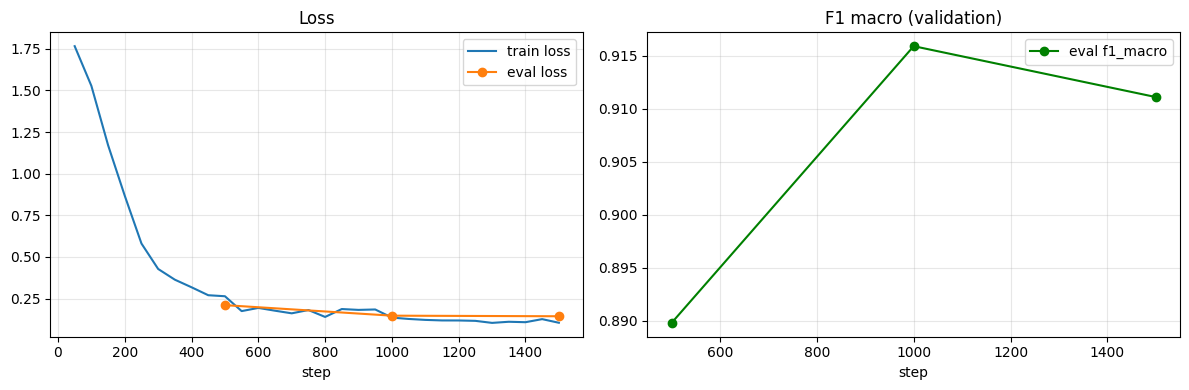

Saved: artifacts/training_curves.png


In [19]:
history_df = pd.DataFrame(trainer.state.log_history)

train_logs = history_df.dropna(subset=["loss"]).copy()
eval_logs  = history_df.dropna(subset=["eval_loss"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(train_logs["step"], train_logs["loss"],       label="train loss")
axes[0].plot(eval_logs["step"],  eval_logs["eval_loss"],   label="eval loss",  marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("step")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 macro
if "eval_f1_macro" in eval_logs.columns:
    axes[1].plot(eval_logs["step"], eval_logs["eval_f1_macro"], label="eval f1_macro", marker="o", color="green")
    axes[1].set_title("F1 macro (validation)")
    axes[1].set_xlabel("step")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/training_curves.png")

In [20]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation:")
for k, v in val_metrics.items():
    print(f"  {k}: {v}")

{'eval_loss': '0.1478', 'eval_accuracy': '0.94', 'eval_f1_macro': '0.9159', 'eval_runtime': '3.224', 'eval_samples_per_second': '620.4', 'eval_steps_per_second': '9.926', 'epoch': '3'}
Validation:
  eval_loss: 0.14782589673995972
  eval_accuracy: 0.94
  eval_f1_macro: 0.9159
  eval_runtime: 3.2239
  eval_samples_per_second: 620.363
  eval_steps_per_second: 9.926
  epoch: 3.0


In [21]:
test_output  = trainer.predict(tokenized_datasets["test"])
test_logits  = test_output.predictions
test_preds   = np.argmax(test_logits, axis=-1)
test_true    = np.array(tokenized_datasets["test"]["labels"])

test_acc = accuracy_score(test_true, test_preds)
test_f1  = f1_score(test_true, test_preds, average="macro")

print("=== Final metrics on TEST ===")
print(f"accuracy: {test_acc:.4f}")
print(f"f1_macro: {test_f1:.4f}")

=== Final metrics on TEST ===
accuracy: 0.9235
f1_macro: 0.8851


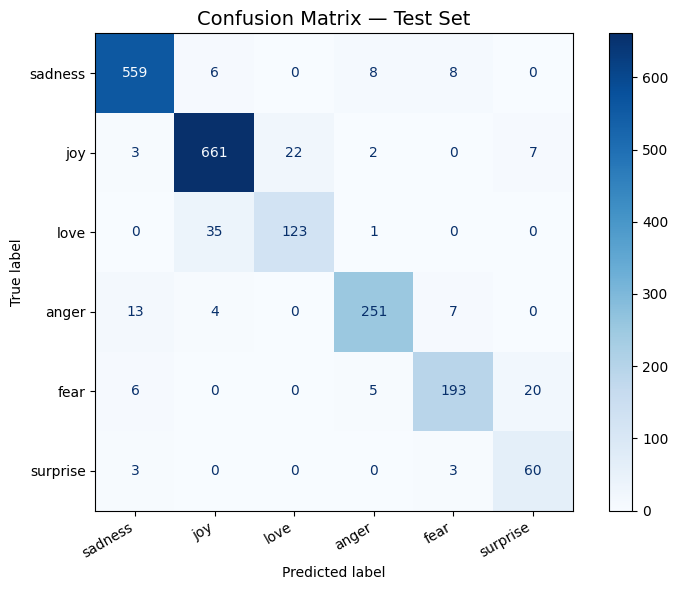

Saved: artifacts/confusion_matrix.png


In [22]:
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/confusion_matrix.png")

In [23]:
import torch.nn.functional as F

test_texts_raw = raw_datasets["test"]["text"]
probs          = F.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=-1).numpy()
confidence     = probs.max(axis=-1)

preds_df = pd.DataFrame({
    "text":        test_texts_raw,
    "true_label":  [id2label[i] for i in test_true],
    "pred_label":  [id2label[i] for i in test_preds],
    "confidence":  confidence.round(3),
    "correct":     (test_true == test_preds),
})

preds_df.head(50).to_csv(ARTIFACTS_DIR / "sample_predictions.csv", index=False)
print("Saved: artifacts/sample_predictions.csv")

display(preds_df.head(10))

Saved: artifacts/sample_predictions.csv


,text,true_label,pred_label,confidence,correct
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.994,True
1,im updating my blog because i feel shitty,sadness,sadness,0.995,True
2,i never make her separate from me because i do...,sadness,sadness,0.995,True
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.994,True
4,i was feeling a little vain when i did this one,sadness,sadness,0.995,True
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.982,True
6,i felt anger when at the end of a telephone call,anger,anger,0.984,True
7,i explain why i clung to a relationship with a...,joy,joy,0.782,True
8,i like to have the same breathless feeling as ...,joy,joy,0.993,True
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.990,True


In [24]:
errors_df = preds_df[~preds_df["correct"]].copy()
print(f"Total test errors: {len(errors_df)} / {len(preds_df)}")

display(errors_df[["text","true_label","pred_label","confidence"]].head(10))

Total test errors: 153 / 2000


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.529
20,im not sure the feeling of loss will ever go a...,sadness,joy,0.618
67,i feel a bit stressed even though all the thin...,anger,sadness,0.582
93,i was feeling weird the other day and it went ...,fear,surprise,0.657
94,when a friend dropped a frog down my neck,anger,fear,0.580
96,i love neglecting this blog but sometimes i fe...,love,joy,0.643
103,i feel agitated with myself that i did not for...,fear,anger,0.576
108,i looked at mabel this morning i named my left...,fear,surprise,0.687
111,i feel is he generous,love,joy,0.544
125,i feel very mislead by someone that i really r...,love,anger,0.894


In [25]:
error_pairs = (
    errors_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Top-10 error pairs (true to pred):")
display(error_pairs.head(10))

Top-10 error pairs (true to pred):


,true_label,pred_label,count
11,love,joy,35
7,joy,love,22
5,fear,surprise,20
2,anger,sadness,13
12,sadness,anger,8
13,sadness,fear,8
0,anger,fear,7
9,joy,surprise,7
4,fear,sadness,6
14,sadness,joy,6
